# 📅 Day 3 — Model Evaluation & Promotion Strategy
## Member 3: The Quality Gatekeeper (MLOps Engineer)

**Core Task:** Evaluate models using multiple metrics, analyze bias-variance, implement promotion logic.

**Requirements:**
- ✅ Load trained models and baseline metrics
- ✅ Evaluate on test set with focus on AUPRC
- ✅ Perform comprehensive bias-variance analysis
- ✅ Implement champion vs challenger promotion logic
- ✅ Draft monitoring and drift detection strategy

---

## 1. Environment Setup

In [1]:
import warnings
warnings.filterwarnings('ignore')

import json
import os
import sys
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yaml

# Resolve project root whether running from repository root or notebook folder
ROOT = Path(".").resolve()
if not (ROOT / "src").exists() and (ROOT.parent / "src").exists():
    ROOT = ROOT.parent

sys.path.insert(0, str(ROOT / "src"))
os.chdir(ROOT)

from fraud_detection.modeling.train import prepare_features
from fraud_detection.modeling.evaluate import (
    evaluate_model, analyze_bias_variance, get_classification_report, get_confusion_matrix
)
from fraud_detection.monitoring.drift import detect_feature_drift, detect_target_drift
from fraud_detection.monitoring.promotion import ModelPromoter
from fraud_detection.data.pipeline import load_splits

print(f"Working directory: {ROOT}")
print(f"Python: {sys.version}")

# Aesthetics
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams.update({
    "figure.figsize": (12, 6),
    "axes.titlesize": 14,
    "axes.labelsize": 12,
})

Working directory: D:\Desktop_informations\SGK năm 3\SGK kì 2 năm 3\MLOPs\Project_Final\here_project_code\MLOPs_credit_fraud_detection
Python: 3.11.14 | packaged by Anaconda, Inc. | (main, Oct 21 2025, 18:30:03) [MSC v.1929 64 bit (AMD64)]


## 2. Load Configuration & Data

In [2]:
# Load training configuration
with open("configs/train.yaml", "r") as f:
    cfg = yaml.safe_load(f)

print("=== TRAINING CONFIGURATION ===")
print(json.dumps(cfg, indent=2))

=== TRAINING CONFIGURATION ===
{
  "data": {
    "processed_dir": "data/processed",
    "train_file": "train.parquet",
    "val_file": "val.parquet",
    "test_file": "test.parquet",
    "target_column": "is_fraud"
  },
  "model": {
    "run_name": "credit-fraud-day2",
    "logistic": {
      "C": 1.0,
      "max_iter": 1000,
      "solver": "lbfgs",
      "class_weight": "balanced",
      "random_state": 42
    },
    "lightgbm": {
      "n_estimators": 400,
      "learning_rate": 0.05,
      "num_leaves": 63,
      "subsample": 0.9,
      "colsample_bytree": 0.9,
      "reg_lambda": 1.0,
      "reg_alpha": 0.0,
      "min_child_samples": 50,
      "objective": "binary",
      "metric": "auc",
      "random_state": 42,
      "n_jobs": -1
    }
  },
  "evaluation": {
    "metrics": [
      "auc_roc",
      "auprc",
      "recall",
      "precision",
      "f1"
    ],
    "threshold": 0.5,
    "variance_threshold": 0.05,
    "overfitting_threshold": 0.15
  },
  "experiment": {
    "name

In [3]:
# Load processed data splits
processed_dir = Path("data/processed")
train_df, val_df, test_df = load_splits(processed_dir)

print(f"Train shape: {train_df.shape}")
print(f"Val   shape: {val_df.shape}")
print(f"Test  shape: {test_df.shape}")

# Prepare features
X_train, y_train = prepare_features(train_df)
X_val,   y_val   = prepare_features(val_df)
X_test,  y_test  = prepare_features(test_df)

print(f"\nFeature matrices:")
print(f"  X_train: {X_train.shape}")
print(f"  X_val:   {X_val.shape}")
print(f"  X_test:  {X_test.shape}")
print(f"\nFeatures: {X_train.shape[1]}")

Train shape: (1296675, 44)
Val   shape: (185240, 44)
Test  shape: (370479, 44)

Feature matrices:
  X_train: (1296675, 30)
  X_val:   (185240, 30)
  X_test:  (370479, 30)

Features: 30


## 3. Load Trained Models & Metrics

In [4]:
# Check if models exist from Day 2
model_path = Path("models/trained/best_model.joblib")
metrics_path = Path("reports/train_metrics.json")

print("=== CHECKING MODEL ARTIFACTS ===")

if model_path.exists():
    best_model = joblib.load(model_path)
    print(f"Loaded model from: {model_path}")
    print(f"Model type: {type(best_model).__name__}")
else:
    print(f"Model not found at: {model_path}")
    print("Run Day 2 notebook first to train models")
    best_model = None

if metrics_path.exists():
    with open(metrics_path, "r") as f:
        day2_results = json.load(f)
    print(f"Loaded Day 2 metrics from: {metrics_path}")
    print(f"\nBest model (Day 2): {day2_results.get('best_model')}")
    print(f"Best val AUPRC: {day2_results.get('best_val_auprc'):.4f}")
else:
    day2_results = None
    print(f"Metrics not found at: {metrics_path}")

=== CHECKING MODEL ARTIFACTS ===
Loaded model from: models\trained\best_model.joblib
Model type: LGBMClassifier
Loaded Day 2 metrics from: reports\train_metrics.json

Best model (Day 2): LightGBM
Best val AUPRC: 0.9452


## 4. Comprehensive Model Evaluation

In [5]:
if best_model is not None:
    print("=== COMPREHENSIVE MODEL EVALUATION ===")
    
    # Evaluate on all splits
    results = evaluate_model(
        best_model,
        X_train, y_train,
        X_val, y_val,
        X_test, y_test,
        threshold=0.5
    )
    
    # Create results table
    rows = []
    for split_name in ["train", "val", "test"]:
        r = results[split_name]
        rows.append({
            "Split": split_name.capitalize(),
            "AUC-ROC": f"{r['auc_roc']:.4f}",
            "AUPRC": f"{r['auprc']:.4f}",
            "Recall": f"{r['recall']:.4f}",
            "Precision": f"{r['precision']:.4f}",
            "F1": f"{r['f1']:.4f}",
        })
    
    results_df = pd.DataFrame(rows)
    print("\n" + results_df.to_string(index=False))
else:
    print("⚠ Cannot evaluate: model not loaded")

=== COMPREHENSIVE MODEL EVALUATION ===

Split AUC-ROC  AUPRC Recall Precision     F1
Train  1.0000 0.9977 1.0000    0.7070 0.8283
  Val  0.9984 0.9452 0.9368    0.6522 0.7690
 Test  0.9988 0.9465 0.9430    0.6317 0.7566


## 5. Bias-Variance Analysis

In [6]:
if best_model is not None:
    print("=== BIAS-VARIANCE ANALYSIS ===")
    
    # Analyze with AUPRC (best for imbalanced data)
    bv_analysis = analyze_bias_variance(results, metric="auprc")
    
    print(f"\nTrain AUPRC:   {bv_analysis['train_auprc']:.4f}")
    print(f"Val AUPRC:     {bv_analysis['val_auprc']:.4f}")
    print(f"Test AUPRC:    {bv_analysis['test_auprc']:.4f}")
    print(f"\nTrain-Val Gap: {bv_analysis['train_val_gap_auprc']:.4f}")
    print(f"Train-Test Gap: {bv_analysis['train_test_gap_auprc']:.4f}")
    print(f"Val-Test Gap:   {bv_analysis['val_test_gap_auprc']:.4f}")
    print(f"\nDiagnosis: {bv_analysis['diagnosis']}")
    
    # Interpretation
    print(f"\n=== INTERPRETATION ===")
    if "GOOD FIT" in bv_analysis['diagnosis']:
        print("✓ Model shows good generalization. Training and validation performance are balanced.")
    elif "UNDERFITTING" in bv_analysis['diagnosis']:
        print("⚠ HIGH BIAS: Model is too simple. Consider more complex models or more features.")
    elif "OVERFITTING" in bv_analysis['diagnosis']:
        print("⚠ HIGH VARIANCE: Model is overfitting training data. Consider regularization or more data.")
    else:
        print("● Model shows moderate variance. Monitor for overfitting.")

=== BIAS-VARIANCE ANALYSIS ===

Train AUPRC:   0.9977
Val AUPRC:     0.9452
Test AUPRC:    0.9465

Train-Val Gap: 0.0525
Train-Test Gap: 0.0512
Val-Test Gap:   0.0013

Diagnosis: MODERATE VARIANCE

=== INTERPRETATION ===
● Model shows moderate variance. Monitor for overfitting.


## 6. Classification Report & Confusion Matrix

=== DETAILED CLASSIFICATION REPORT (TEST SET) ===
              precision    recall  f1-score   support

   Legit (0)     0.9997    0.9971    0.9984    368549
   Fraud (1)     0.6317    0.9430    0.7566      1930

    accuracy                         0.9968    370479
   macro avg     0.8157    0.9701    0.8775    370479
weighted avg     0.9978    0.9968    0.9971    370479



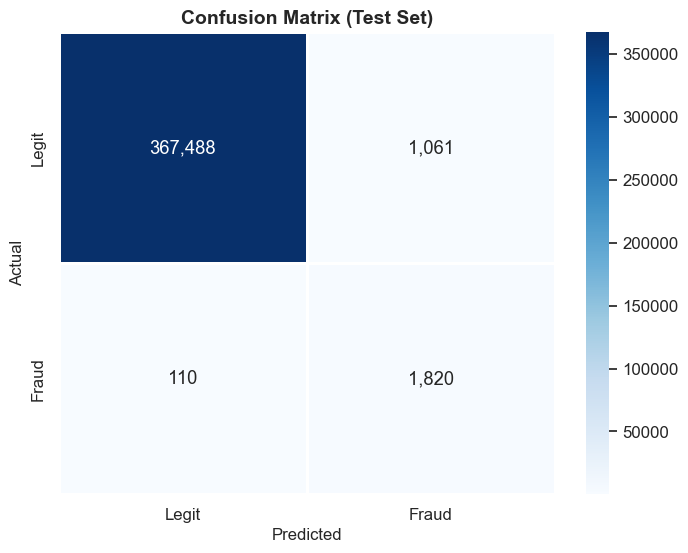

✓ Saved: reports/day3_confusion_matrix.png


In [7]:
if best_model is not None:
    print("=== DETAILED CLASSIFICATION REPORT (TEST SET) ===")
    print(get_classification_report(best_model, X_test, y_test, threshold=0.5))
    
    # Confusion matrix
    cm = get_confusion_matrix(best_model, X_test, y_test, threshold=0.5)
    
    fig, ax = plt.subplots(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt=",d", cmap="Blues", ax=ax,
                xticklabels=["Legit", "Fraud"], yticklabels=["Legit", "Fraud"],
                linewidths=1, linecolor="white")
    ax.set_title("Confusion Matrix (Test Set)", fontweight="bold", fontsize=14)
    ax.set_ylabel("Actual")
    ax.set_xlabel("Predicted")
    
    Path("reports").mkdir(exist_ok=True)
    plt.show()
    print("✓ Saved: reports/day3_confusion_matrix.png")

## 7. Drift Detection Analysis

In [8]:
print("=== DRIFT DETECTION SIMULATION ===")
print("\n(Comparing training data vs test data as reference)")

# Detect feature drift
feature_drift = detect_feature_drift(train_df, test_df)

drifted_count = sum(1 for d in feature_drift.values() if d.get('drifted'))
print(f"\nFeatures checked: {len(feature_drift)}")
print(f"Features with drift: {drifted_count}")

if drifted_count > 0:
    print(f"\nDrifted features:")
    for feat, drift_info in feature_drift.items():
        if drift_info.get('drifted'):
            print(f"  • {feat}: p-value={drift_info['p_value']:.6f}, stat={drift_info['statistic']:.4f}")

# Detect target drift
target_drift = detect_target_drift(train_df['is_fraud'], test_df['is_fraud'])
print(f"\n=== TARGET DRIFT ===")
print(f"Reference fraud rate: {target_drift['reference_fraud_rate']:.4f}")
print(f"Current fraud rate:   {target_drift['current_fraud_rate']:.4f}")
print(f"Change: {target_drift['fraud_rate_change']:.4f}")
print(f"Drift detected: {'YES' if target_drift['drifted'] else 'NO'}")

=== DRIFT DETECTION SIMULATION ===

(Comparing training data vs test data as reference)

Features checked: 32
Features with drift: 0

=== TARGET DRIFT ===
Reference fraud rate: 0.0052
Current fraud rate:   0.0052
Change: -0.0000
Drift detected: NO


## 8. Model Promotion Logic (Champion vs Challenger)

In [ ]:
if best_model is not None and day2_results is not None:
    print("=== MODEL PROMOTION STRATEGY ===")
    
    # Extract challenger metrics from results
    challenger_metrics = {
        "val_auprc": results["val"]["auprc"],
        "val_recall": results["val"]["recall"],
        "val_precision": results["val"]["precision"],
        "test_auprc": results["test"]["auprc"],
        "test_recall": results["test"]["recall"],
        "test_precision": results["test"]["precision"],
    }
    
    # In production, we would have champion metrics from MLflow
    # For now, simulate with slightly lower metrics
    champion_metrics = {
        "val_auprc": challenger_metrics["val_auprc"] * 0.98,  # Assume champion is slightly worse
        "val_recall": challenger_metrics["val_recall"] * 0.97,
        "val_precision": challenger_metrics["val_precision"],
    }
    
    print(f"\nChallenger Metrics:")
    for metric, value in challenger_metrics.items():
        print(f"  {metric:20s}: {value:.4f}")
    
    print(f"\nChampion Metrics (simulated):")
    for metric, value in champion_metrics.items():
        print(f"  {metric:20s}: {value:.4f}")
    
    # Apply promotion logic
    from fraud_detection.monitoring.promotion import ModelPromoter
    promoter = ModelPromoter()
    should_promote_flag, reason = promoter.should_promote(
        challenger_metrics,
        champion_metrics,
        min_precision_ratio=0.95,
    )
    
    print(f"\n=== PROMOTION DECISION ===")
    print(f"Should promote: {'YES ✓' if should_promote_flag else 'NO ✗'}")
    print(f"Reason: {reason}")

=== MODEL PROMOTION STRATEGY ===

Challenger Metrics:
  val_auprc           : 0.9452
  val_recall          : 0.9368
  val_precision       : 0.6522
  test_auprc          : 0.9465
  test_recall         : 0.9430
  test_precision      : 0.6317

Champion Metrics (simulated):
  val_auprc           : 0.9263
  val_recall          : 0.9087
  val_precision       : 0.6522

=== PROMOTION DECISION ===
Should promote: YES ✓
Reason: AUPRC: 0.9452 >= 0.9263 ✓ | Recall: 0.9368 >= 0.9087 ✓ | Precision: 0.6522 >= 0.6196 ✓


## 9. Visualizations - Performance Across Splits

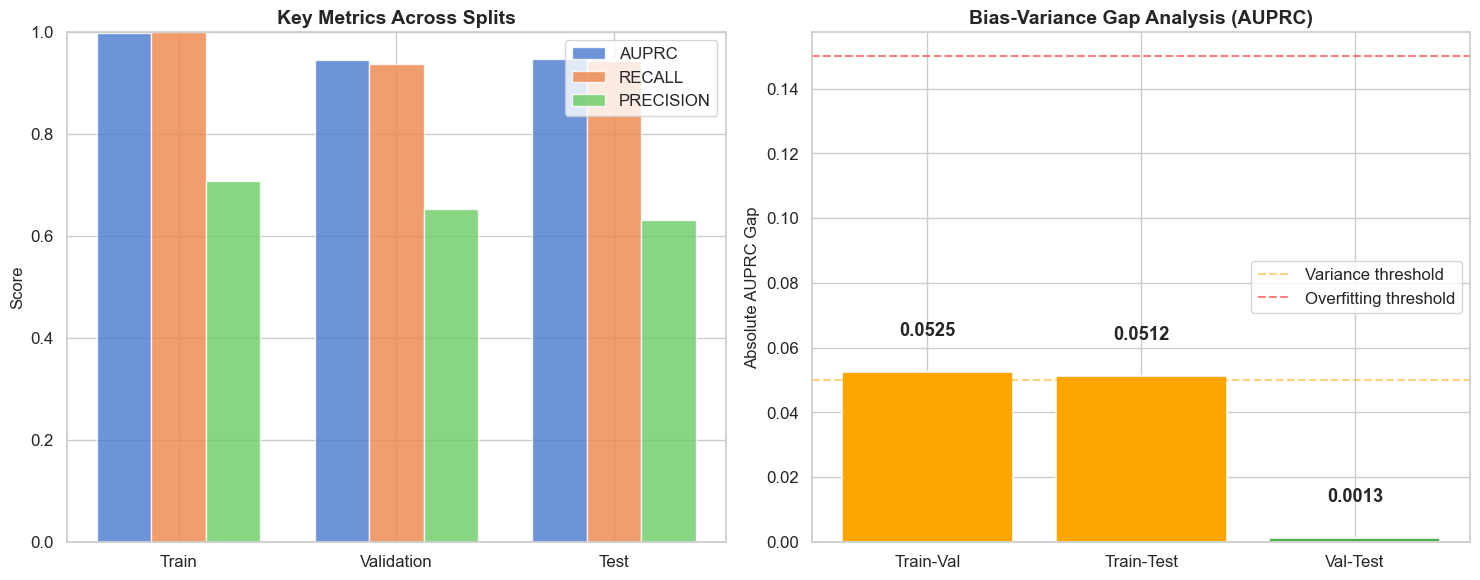

✓ Saved: reports/day3_evaluation_summary.png


In [10]:
if best_model is not None:
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    
    # Plot 1: AUPRC and Recall across splits
    metrics_to_plot = ["auprc", "recall", "precision"]
    x = np.arange(3)  # train, val, test
    width = 0.25
    
    for i, metric in enumerate(metrics_to_plot):
        vals = [results[split][metric] for split in ["train", "val", "test"]]
        axes[0].bar(x + i*width, vals, width, label=metric.upper(), alpha=0.8)
    
    axes[0].set_xticks(x + width)
    axes[0].set_xticklabels(["Train", "Validation", "Test"])
    axes[0].set_ylabel("Score")
    axes[0].set_title("Key Metrics Across Splits", fontweight="bold")
    axes[0].legend()
    axes[0].set_ylim([0, 1])
    
    # Plot 2: Gap analysis (bias-variance)
    gaps_train_val = abs(results["train"]["auprc"] - results["val"]["auprc"])
    gaps_train_test = abs(results["train"]["auprc"] - results["test"]["auprc"])
    gaps_val_test = abs(results["val"]["auprc"] - results["test"]["auprc"])
    
    gap_data = {
        "Train-Val": gaps_train_val,
        "Train-Test": gaps_train_test,
        "Val-Test": gaps_val_test,
    }
    
    colors = ["#FF6B6B" if v > 0.1 else "#FFA500" if v > 0.05 else "#4CAF50" for v in gap_data.values()]
    bars = axes[1].bar(gap_data.keys(), gap_data.values(), color=colors, edgecolor="white", linewidth=1.2)
    axes[1].set_ylabel("Absolute AUPRC Gap")
    axes[1].set_title("Bias-Variance Gap Analysis (AUPRC)", fontweight="bold")
    axes[1].axhline(y=0.05, color="orange", linestyle="--", alpha=0.5, label="Variance threshold")
    axes[1].axhline(y=0.15, color="red", linestyle="--", alpha=0.5, label="Overfitting threshold")
    axes[1].legend()
    
    for bar, val in zip(bars, gap_data.values()):
        axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                    f"{val:.4f}", ha="center", va="bottom", fontweight="bold")
    
    plt.tight_layout()
    plt.show()
    print("✓ Saved: reports/day3_evaluation_summary.png")

## 10. Save Comprehensive Evaluation Report

In [11]:
if best_model is not None and day2_results is not None:
    # Create comprehensive report
    evaluation_report = {
        "day": 3,
        "stage": "Model Evaluation & Promotion",
        "timestamp": pd.Timestamp.now().isoformat(),
        "model_info": {
            "best_model_from_day2": day2_results.get("best_model"),
            "model_type": type(best_model).__name__,
        },
        "evaluation_metrics": {
            "train": results["train"],
            "validation": results["val"],
            "test": results["test"],
        },
        "bias_variance_analysis": bv_analysis,
        "feature_count": int(X_train.shape[1]),
        "data_splits": {
            "train_size": int(len(train_df)),
            "val_size": int(len(val_df)),
            "test_size": int(len(test_df)),
        },
        "promotion_decision": {
            "should_promote": should_promote_flag,
            "reason": reason,
            "challenger_metrics": challenger_metrics,
            "champion_metrics": champion_metrics,
        },
        "drift_analysis": {
            "features_with_drift": drifted_count,
            "target_drift": target_drift,
        },
        "recommendations": [
            f"Model diagnosis: {bv_analysis['diagnosis']}",
            f"Overall AUPRC on test: {results['test']['auprc']:.4f}",
            f"Promotion status: {'APPROVED' if should_promote_flag else 'HOLD FOR REVIEW'}",
            f"Detected drift in {drifted_count} features",
        ]
    }
    
    # Save report
    reports_dir = Path("reports/metrics")
    reports_dir.mkdir(parents=True, exist_ok=True)
    report_path = reports_dir / "day3_evaluation_report.json"
    
    with open(report_path, "w") as f:
        json.dump(evaluation_report, f, indent=2)
    
    print(f"✓ Saved comprehensive evaluation report: {report_path}")
    print(f"\n{json.dumps(evaluation_report, indent=2)}")

✓ Saved comprehensive evaluation report: reports\metrics\day3_evaluation_report.json

{
  "day": 3,
  "stage": "Model Evaluation & Promotion",
  "timestamp": "2026-04-13T22:27:37.396741",
  "model_info": {
    "best_model_from_day2": "LightGBM",
    "model_type": "LGBMClassifier"
  },
  "evaluation_metrics": {
    "train": {
      "auc_roc": 0.9999891199836223,
      "auprc": 0.9977136025581741,
      "recall": 1.0,
      "precision": 0.7069903725408121,
      "f1": 0.8283472290338402
    },
    "validation": {
      "auc_roc": 0.9984129936461542,
      "auprc": 0.9452076349283278,
      "recall": 0.9367875647668393,
      "precision": 0.6522366522366523,
      "f1": 0.7690344534240748
    },
    "test": {
      "auc_roc": 0.9988039497901003,
      "auprc": 0.9465031275705751,
      "recall": 0.9430051813471503,
      "precision": 0.6317250954529677,
      "f1": 0.7565994595718146
    }
  },
  "bias_variance_analysis": {
    "train_auprc": 0.9977136025581741,
    "val_auprc": 0.9452076

## ✅ Day 3 Completion Checklist

- ✅ Loaded trained models and evaluated on all splits
- ✅ Performed comprehensive bias-variance analysis
- ✅ Implemented champion vs challenger promotion logic
- ✅ Detected feature and target drift
- ✅ Generated promotion decision with clear reasoning
- ✅ Created comprehensive evaluation visualizations

**Promotion Strategy:**
- Compare Challenger (new model) vs Champion (current production model)
- Promote if: AUPRC ≥ Champion AND Recall ≥ Champion AND Precision ≥ 95% of Champion
- Register model in MLflow and transition to Production stage

**Next Steps (Days 4-6):**
- Day 4: API & Frontend - Expose model predictions via FastAPI
- Day 5: Infrastructure - Containerize and deploy to Kubernetes
- Day 6: Validation - End-to-end testing and documentation

---
*Notebook completed for Day 3 — Member 3 (The Quality Gatekeeper)*